# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     | Juan Pablo Moran |
| **Fecha**      | 05/10/2026 |
| **Expediente** | 753760 |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [1]:
import pandas as pd

data = pd.read_csv("Default.csv")
print(data.shape)

(10000, 4)


2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [2]:
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [3]:
data.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

In [4]:
data.dtypes

default        str
student        str
balance    float64
income     float64
dtype: object

- Hay 4 columnas: `default`, `student`, `balance` e `income`
- `default` y `student` son de texto (object / str) con valores "Yes" / "No", por eso no salen en describe
- `balance` e `income` son numericas (float64)
- `balance` es el saldo que la persona trae en su tarjeta y `income` es su ingreso anual

4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [5]:
data["default"] = data["default"].astype("category")
data["student"] = data["student"].astype("category")
data.dtypes

default    category
student    category
balance     float64
income      float64
dtype: object

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

<Axes: title={'center': 'income'}, xlabel='default'>

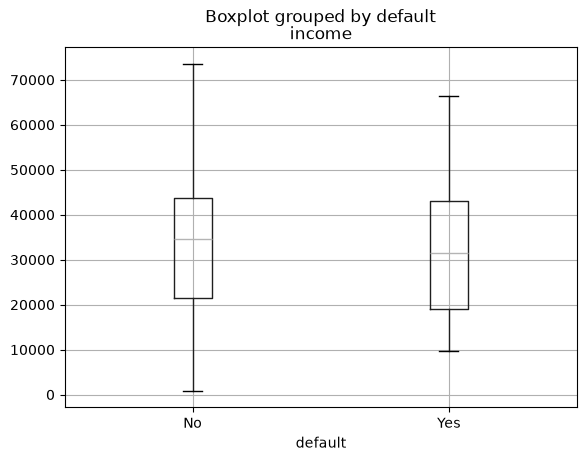

In [6]:
data.boxplot(column="income", by="default")

<Axes: title={'center': 'balance'}, xlabel='default'>

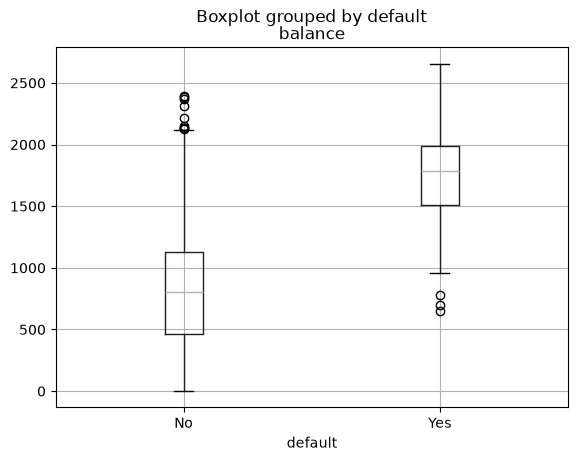

In [7]:
data.boxplot(column="balance", by="default")

- El ingreso (`income`) es muy parecido entre los que pagaron y los que no, no parece separar a los grupos
- El balance si cambia mucho: las personas que hicieron default tienen un balance bastante mas alto

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

<Axes: xlabel='balance', ylabel='income'>

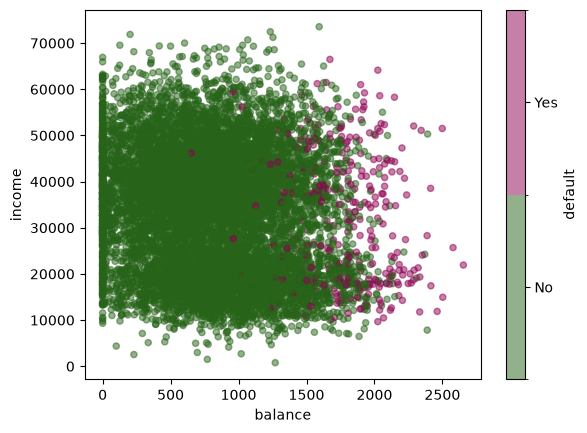

In [8]:
data.plot.scatter(x="balance", y="income", c="default", colormap="PiYG_r", alpha=0.5)

- Los puntos de default se juntan del lado derecho (balance alto) sin importar el ingreso
- Otra vez se ve que `balance` es el factor que mas ayuda a separar las clases

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías. 

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [9]:
y = data["default"] == "Yes"
x = data[["balance"]]
print(y.sum(), "personas hicieron default de", len(y))

333 personas hicieron default de 10000


Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

Text(0, 0.5, 'default')

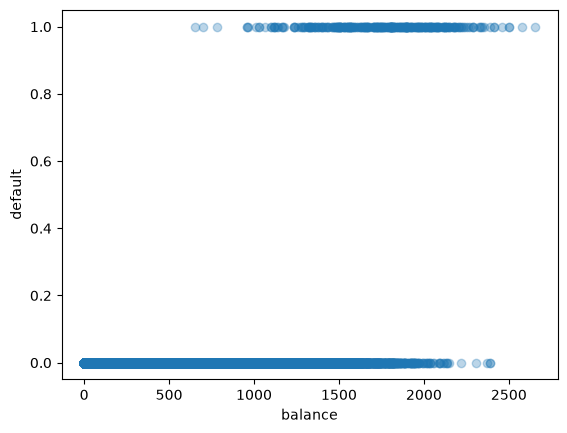

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(x, y, alpha=0.3)
plt.xlabel("balance")
plt.ylabel("default")

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x, y)
print("b0 =", lr.intercept_[0])
print("b1 =", lr.coef_[0][0])

b0 = -10.65132823650608
b1 = 0.005498915547165412


Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [12]:
import numpy as np

p = lr.predict_proba(x)[:, 1]
p

array([1.30568146e-03, 2.11259754e-03, 8.59474814e-03, ...,
       2.46651596e-03, 1.16759635e-01, 7.14476480e-05], shape=(10000,))

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [13]:
w = p * (1 - p)
w

array([1.30397665e-03, 2.10813447e-03, 8.52087844e-03, ...,
       2.46043226e-03, 1.03126823e-01, 7.14425432e-05], shape=(10000,))

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [14]:
V = np.diagflat(w)
V.shape

(10000, 10000)

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [15]:
import statsmodels.api as sm

X = sm.add_constant(x.values)
cov = np.linalg.inv(X.T @ V @ X)
cov

array([[ 1.30442757e-01, -7.81757265e-05],
       [-7.81757265e-05,  4.85656561e-08]])

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [16]:
se = np.sqrt(np.diag(cov))
print("SE(b0) =", se[0])
print("SE(b1) =", se[1])

SE(b0) = 0.3611685997248206
SE(b1) = 0.00022037616946916634


Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [17]:
b = np.array([lr.intercept_[0], lr.coef_[0][0]])
z = b / se
print("z(b0) =", z[0])
print("z(b1) =", z[1])

z(b0) = -29.491290894672115
z(b1) = 24.95240551830531


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [18]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z)))
print("p-value b0 =", p_value[0])
print("p-value b1 =", p_value[1])

p-value b0 = 0.0
p-value b1 = 0.0


¿Es significativa la relación de los factores con la variable de respuesta?

- Si, el p-value de `balance` es practicamente 0 (z de mas de 20), mucho menor a 0.05
- Rechazamos que b1 = 0, entonces si hay relacion entre el balance y la probabilidad de default
- b1 es positivo: entre mas balance, mas probabilidad de dejar de pagar

Repite el procedimiento con el factor `student`. 
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes. 
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [19]:
# 1. Transformar student a 1 y 0
x2 = (data[["student"]] == "Yes").astype(int)

lr2 = LogisticRegression()
lr2.fit(x2, y)
print("b0 =", lr2.intercept_[0])
print("b1 =", lr2.coef_[0][0])

b0 = -3.5025724918531327
b1 = 0.396208884768655


In [20]:

p2 = lr2.predict_proba(x2)[:, 1]
V2 = np.diagflat(p2 * (1 - p2))
X2 = sm.add_constant(x2.values)
cov2 = np.linalg.inv(X2.T @ V2 @ X2)
se2 = np.sqrt(np.diag(cov2))
print("SE(b0) =", se2[0])
print("SE(b1) =", se2[1])

SE(b0) = 0.07066142671068854
SE(b1) = 0.11522061447776837


In [21]:

b2 = np.array([lr2.intercept_[0], lr2.coef_[0][0]])
z2 = b2 / se2
p_value2 = 2 * (1 - norm.cdf(abs(z2)))
print("z =", z2)
print("p-value =", p_value2)

z = [-49.56838058   3.4386979 ]
p-value = [0.         0.00058452]


- El p-value de `student` es menor a 0.05, entonces si es significativo por si solo
- b1 es positivo: ser estudiante sube la probabilidad de default cuando no tomamos en cuenta nada mas

## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*. 

In [22]:

x3 = data[["balance", "income"]].copy()
x3["student"] = (data["student"] == "Yes").astype(int)

lr3 = LogisticRegression()
lr3.fit(x3, y)
print("b0 =", lr3.intercept_[0])
print("b1, b2, b3 =", lr3.coef_[0])

b0 = -10.901811600666454
b1, b2, b3 = [ 5.73060606e-03  3.96189934e-06 -6.12564503e-01]


In [23]:

p3 = lr3.predict_proba(x3)[:, 1]
V3 = np.diagflat(p3 * (1 - p3))
X3 = sm.add_constant(x3.values)
cov3 = np.linalg.inv(X3.T @ V3 @ X3)
se3 = np.sqrt(np.diag(cov3))
print("SE =", se3)

SE = [4.93158471e-01 2.31675368e-04 8.20844306e-06 2.36393921e-01]


In [24]:

b3 = np.concatenate([lr3.intercept_, lr3.coef_[0]])
z3 = b3 / se3
p_value3 = 2 * (1 - norm.cdf(abs(z3)))

resultados = pd.DataFrame({"coef": b3, "SE": se3, "z": z3, "p-value": p_value3},
                          index=["intercepto", "balance", "income", "student"])
resultados

,coef,SE,z,p-value
intercepto,-10.901812,0.493158,-22.106102,0.000000
balance,0.005731,0.000232,24.735500,0.000000
income,0.000004,0.000008,0.482661,0.629336
student,-0.612565,0.236394,-2.591287,0.009562


- `balance` y `student` tienen p-value menor a 0.05, son significativos
- `income` tiene p-value mayor a 0.05, no es significativo cuando ya estan balance y student
- Ojo: en el modelo simple `student` era positivo y aqui es negativo. Esto pasa porque los estudiantes suelen tener mas balance; a un mismo balance, un estudiante tiene menos probabilidad de default que un no estudiante (confusion entre variables)

¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.

- Filtro de spam: si un correo importante (una oferta de trabajo) se marca como spam y se pierde, es peor que dejar pasar un spam a la bandeja
- Sistema judicial: declarar culpable a una persona inocente es peor que dejar libre a un culpable

2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.

- Diagnostico de una enfermedad grave (ej. cancer): decirle a alguien enfermo que esta sano hace que no reciba tratamiento a tiempo
- Deteccion de fraude o de default en el banco: aprobarle un credito a alguien que no va a pagar cuesta mas que revisar de mas a alguien que si iba a pagar

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3